### Analyzes the fraction for Greenland

In [1]:
#load the relevant packages. 

import importlib
import sys
sys.path.append('../code')

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd

import cartopy.crs as ccrs
import cartopy.feature as cfeature

import Kyrafunctions as ky

import SeaLevelContrib as slc

import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('retina')

In [2]:
importlib.reload(slc)
importlib.reload(ky)

<module 'Kyrafunctions' from 'C:\\Users\\kyrab\\Github\\SLBudget\\notebooks\\Kyrafunctions.py'>

In [3]:
#Define data paths: 
data_path = '../data/GravIs/'
Gravis_dir = '../outputs/Gravis_Antarctica/'

In [4]:
# Create yearly dataset based on the data from GravIS

#Antarctica: 
ant = xr.open_dataset(data_path + "GRAVIS-3_COSTG_0100_AIS_GRID_TUD_0003.nc")
ant_y = ky.yearlygrace(ant) 

#Greenland: 
gre = xr.open_dataset(data_path + "GRAVIS-3_COSTG_0100_GIS_GRID_TUD_0003.nc")
gre_y = ky.yearlygrace(gre) 

#display(ant_y)

In [16]:
# Opens the dataset containing the the spatial patterns of sea level change based on the mass changes from GravIS and created using the sea level equation. 
# The sea level changes at the Dutch coast can be calculated based on this.

Gravis_ant_ds = xr.open_dataset(f'{Gravis_dir}Gravis_Ant_clean.nc')
Gravis_gre_ds = xr.open_dataset(f'{Gravis_dir}Gravis_Gre_clean.nc')

#Optional: scale data by factor 1.2 or 1.1837950465122913
Gravis_ant_ds['IS_Gravis'] = Gravis_ant_ds['IS_Gravis']*1.1837950465122913
Gravis_ant_ds['Meanslr'] = Gravis_ant_ds['Meanslr']*1.1837950465122913

#display(Gravis_ant_ds)
#display(Gravis_gre_ds)
#Gravis_ant_ds['IS_Gravis'].isel(time=-1).plot()

### Plot the sea level change at tide gauge station due to Greenland mass change pattern

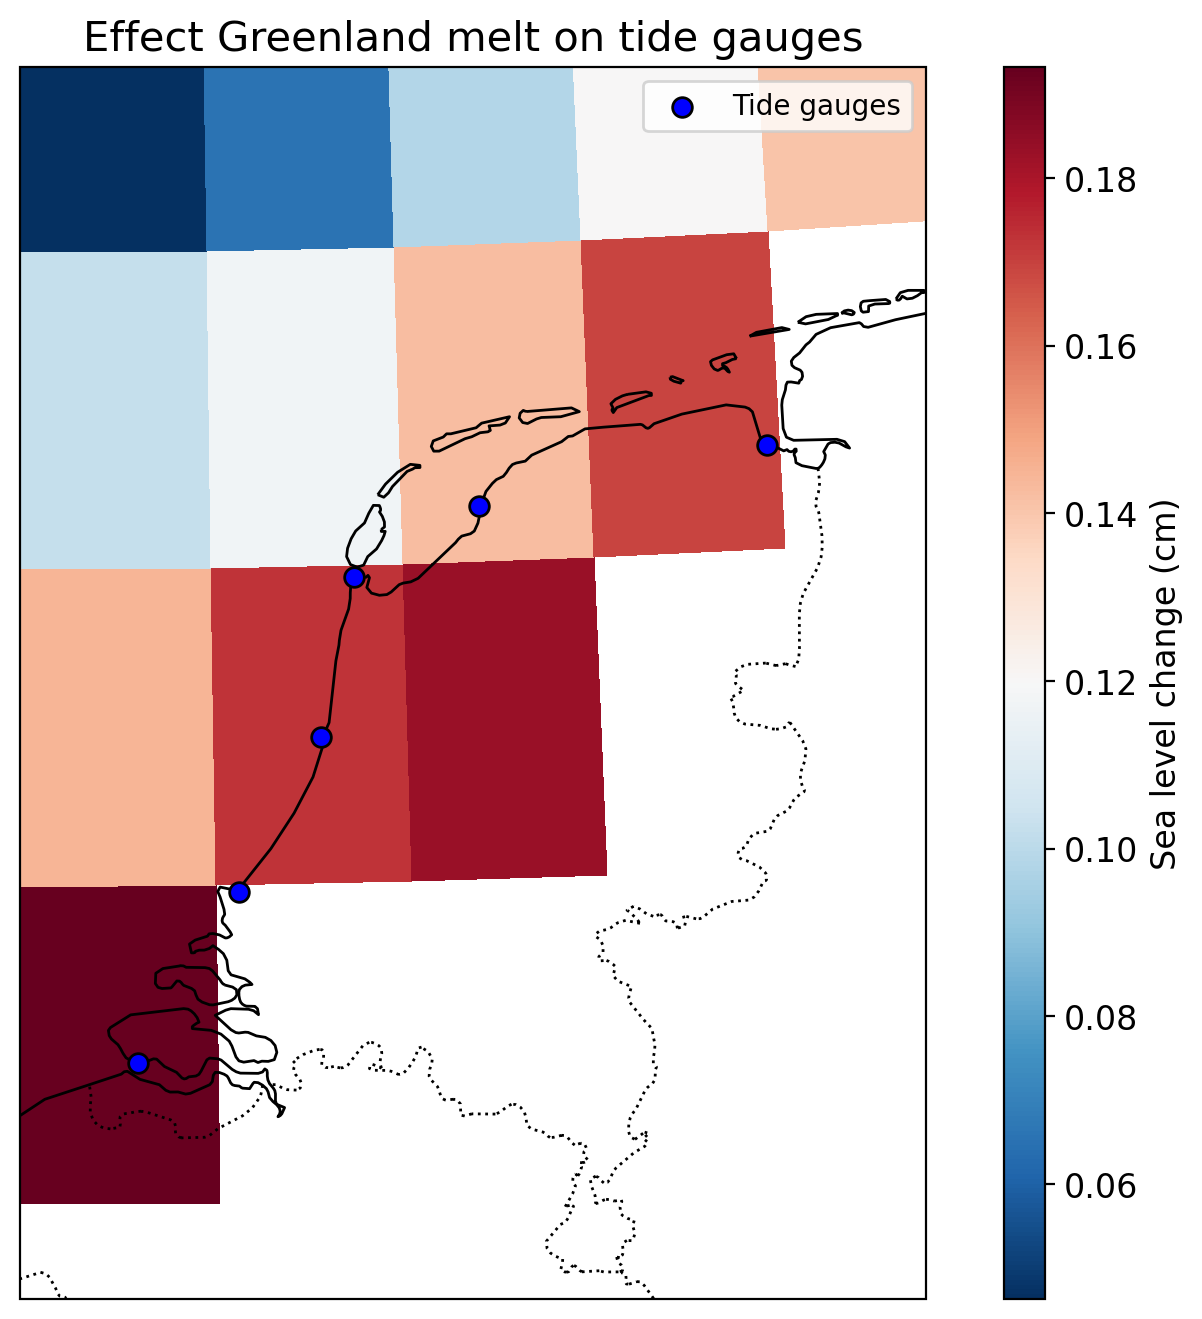

In [17]:
# Pot the sea level rise due to mass changes in Greenland for the Dutch coast 

# Use proper projections for the Duthc coast
proj = ccrs.UTM(zone=31)

# List the considered tg-stations
tg_id = [20, 22, 23, 24, 25, 32]

# Extract coordinates
tg_coords = [slc.tg_lat_lon(tg) for tg in tg_id]
tg_lats = [c[0] for c in tg_coords]
tg_lons = [c[1] for c in tg_coords]

# Extent of the Netherlands (lon/lat)
NL_EXTENT = [3.0, 7.5, 50.7, 54.5]

# Select region (Same extent)
da_region = Gravis_gre_ds['IS_Gravis'].sel(
    lon=slice(NL_EXTENT[0], NL_EXTENT[1]),
    lat=slice(NL_EXTENT[2], NL_EXTENT[3])
)

# Pick a specific time in the dataset if it has a time dimension
if 'time' in da_region.dims:
    da_region = da_region.isel(time=-1)

# Plot
fig, ax = plt.subplots(
    figsize=(10, 8),
    subplot_kw={'projection': proj}
)

im = da_region.plot(
    ax=ax,
    cmap='RdBu_r',
    add_colorbar=True,
    transform=ccrs.PlateCarree(),
    cbar_kwargs={
        'label': 'Sea level change (cm)',
        'shrink': 1,
        'aspect': 30
    }
)

# Formattin colorbar
cbar = im.colorbar
cbar.set_label('Sea level change (cm)', fontsize=12)
cbar.ax.tick_params(labelsize=12)

# Coastlines and borders
ax.coastlines(resolution='10m', zorder=1)
ax.add_feature(cfeature.BORDERS, linestyle=':')

# Scatter the tide gauge stations
ax.scatter(
    tg_lons,
    tg_lats,
    color='blue',
    edgecolor='black',
    s=50,
    marker='o',
    label='Tide gauges',
    zorder=10,
    transform=ccrs.PlateCarree()
)

# Apply excact same extent
ax.set_extent(NL_EXTENT, crs=ccrs.PlateCarree())

ax.set_title('Effect Greenland melt on tide gauges', fontsize=15)
ax.legend()

plt.show()


### Calculate the mean sea level rise at the Dutch coast (mean over tide gauge stations) 

In [7]:
## load file with rise antarctica to calculate the fraction: 
tg_id = [20, 22, 23, 24, 25, 32] #tg stations to calculate the mean @dutch coast #use 23 in stead of 22 for now 

all_GRAVANT = []
all_GRAVGRE = []

for tg in tg_id: 
    tg_coord = slc.tg_lat_lon(tg)
    sel_da = Gravis_ant_ds['IS_Gravis'].ffill('lon', 3).bfill('lon', 3)
    sel_da_gre = Gravis_gre_ds['IS_Gravis'].ffill('lon', 3).bfill('lon', 3)
    loc_da = sel_da.sel(lat = tg_coord[0], 
                    lon = tg_coord[1], 
                    method = 'nearest')
    loc_da_gre = sel_da_gre.sel(lat = tg_coord[0], 
                    lon = tg_coord[1], 
                    method = 'nearest')

    fr_name = {
        'tws' : 'TWS', 
        'AIS' : 'Antarctica', 
        'GrIS' : 'Greenland', 
        'glac' : 'Glaciers',
        'grav': 'Ant_gravis',
        'grav2': 'Gre_gravis'}
 
    GRAVANT = loc_da.squeeze().reset_coords(drop=True).to_dataframe(name=fr_name['grav']) 
    GRAVGRE = loc_da_gre.squeeze().reset_coords(drop=True).to_dataframe(name=fr_name['grav2'])  
    #print(f'tgid{tg}')
    #display(GRAVANT)
    all_GRAVANT.append(GRAVANT)
    all_GRAVGRE.append(GRAVGRE)


# Compute mean of tide gauges: 

def mean_across_gauges(list_of_series):
    return pd.concat(list_of_series, axis=1).mean(axis=1)

# Compute mean time series for each contribution
mean_GRAVANT = mean_across_gauges(all_GRAVANT)
mean_GRAVGRE = mean_across_gauges(all_GRAVGRE)

# Combine all mean series into a single dataframe
mean_df = pd.DataFrame({
    #'Antarctica_mean': mean_ANT,
   # 'Greenland_mean': mean_GRE,
    'Ant_gravis_mean': mean_GRAVANT,
    'Gre_gravis_mean': mean_GRAVGRE
})


# Ensure the index is numeric or datetime
mean_df.index = pd.to_numeric(mean_df.index, errors='coerce')


#display(all_GRAVANT)
display(mean_df)

,Ant_gravis_mean,Gre_gravis_mean
time,,
2002,0.000000,0.000000
2003,0.029048,0.009851
2004,0.059572,0.013824
2005,0.070121,0.011643
2006,0.058111,0.015205
2007,0.101027,0.019718
2008,0.183176,0.032020
2009,0.168140,0.044154
2010,0.218463,0.054499


In [8]:
print(type(mean_df['Ant_gravis_mean']))
print(type(Gravis_ant_ds['Meanslr']))

<class 'pandas.core.series.Series'>
<class 'xarray.core.dataarray.DataArray'>


### Calculate the fraction (based on cummulative data, yearly data and the corresponing running means) 

In [9]:
# Fraction cummulative data:
dutch_coast = mean_df['Gre_gravis_mean'] # dutch coast raw values - factor 1.2 is used. 
mean_world = Gravis_gre_ds['Meanslr'].to_series()  #this is now a data array but to make sure it works thte same translate it to a series , factor 1.2 is used 
fraction = dutch_coast/mean_world

#display(mean_world)

# Fractom using yearly data: 
dutch_c = dutch_coast.diff()  # dutch coast per year
mean_w = mean_world.diff() #global mean per year 
fractionperyear = dutch_c/mean_w

# Cummulative data running mean: 
dutch_coast_5y = dutch_coast.rolling(window=5, center=True).mean()   #min periods=1 uses less data at the boundaries
mean_world_5y   = mean_world.rolling(window=5, center=True).mean()
fraction_5y = dutch_coast_5y/mean_world_5y

# Yearly data running
dutch_c_5y =  dutch_c.rolling(window=5, center=True).mean() 
mean_w_5y =  mean_w.rolling(window=5, center=True).mean()
fractionperyearrun = dutch_c_5y/mean_w_5y

# Yearly data running method 2
dutrun = dutch_coast_5y.diff()   #min periods=1 uses less data at the boundaries
worldrun = mean_world_5y.diff()
peryearfrac = dutrun/worldrun



combined2= pd.DataFrame({
   # 'Dutch coast': dutch_coast, 
   # 'Global mean sea level rise': mean_world,
   # 'Fraction (Dutch/global mean )': fraction,

   # 'Dutch coast running mean 5y': dutch_coast_5y,
   # 'Global running mean 5y': mean_world_5y, 
   # 'Fraction using running means': fraction_5y,
    
   # 'Dutch absolute': dutch_c,
   # 'Global absoolute': mean_w,
   # 'Fraction per year': fractionperyear,
    
    'Dutch absolute running': dutch_c_5y, 
    'Global mean absolute running 5y': mean_w_5y,
    'Fraction running per year': fractionperyearrun
})

display(combined2)


#Styling parameters ror fancy table: 
def highlight_fraction_cols(s):
    """Highlights columns with 'Fraction' in their name."""
    is_fraction = 'Fraction' in s.name
    return ['background-color: lightyellow' if is_fraction else '' for _ in s]


# 1. Border after the 1st column ('Dutch coast') to exclude it from the main grouping.
# 2. Borders after columns 4, 7, and 10 to group the remaining 11 columns into (3, 3, 3, 2).
#    (These columns are Global, Fraction, Dutch)
styles = [
    # Border after the 1st column (excluding it from the main 3-grouping)
    {'selector': 'th.col_heading.level0:nth-child(1)', 'props': [('border-right', '3px solid #666666')]},
    {'selector': 'td:nth-child(1)', 'props': [('border-right', '3px solid #666666')]},

    # Borders after the 4th, 7th, and 10th columns to create the triplets
    # (Global mean SL, Fraction, Dutch coast running mean 5y) and subsequent groups
    {'selector': 'th.col_heading.level0:nth-child(4)', 'props': [('border-right', '3px solid #666666')]},
    {'selector': 'td:nth-child(4)', 'props': [('border-right', '3px solid #666666')]},
    
    {'selector': 'th.col_heading.level0:nth-child(7)', 'props': [('border-right', '3px solid #666666')]},
    {'selector': 'td:nth-child(7)', 'props': [('border-right', '3px solid #666666')]},
    
    {'selector': 'th.col_heading.level0:nth-child(10)', 'props': [('border-right', '3px solid #666666')]},
    {'selector': 'td:nth-child(10)', 'props': [('border-right', '3px solid #666666')]}
]

combined2_2005 = combined2.loc[2005:] 

# --- Apply the Styling ---
styled_combined2_2005 = (
    combined2_2005.style
    # Apply the highlighting to the Fraction columns
    .apply(highlight_fraction_cols, axis=0) 
    # Apply the visual grouping borders
    .set_table_styles(styles)
    # Format all numeric columns to 4 decimal places
    .format('{:.4f}')
)

# --- Display the styled table ---
display(styled_combined2_2005)


,Dutch absolute running,Global mean absolute running 5y,Fraction running per year
time,,,
2002,NaN,NaN,NaN
2003,NaN,NaN,NaN
2004,NaN,NaN,NaN
2005,0.003944,0.047471,0.083075
2006,0.004434,0.058231,0.076140
2007,0.006066,0.058568,0.103572
2008,0.008571,0.065518,0.130823
2009,0.010059,0.076815,0.130955
2010,0.011751,0.083546,0.140656


,Dutch absolute running,Global mean absolute running 5y,Fraction running per year
time,,,
2005,0.0039,0.0475,0.0831
2006,0.0044,0.0582,0.0761
2007,0.0061,0.0586,0.1036
2008,0.0086,0.0655,0.1308
2009,0.0101,0.0768,0.1310
2010,0.0118,0.0835,0.1407
2011,0.0109,0.0850,0.1280
2012,0.0099,0.0819,0.1209
2013,0.0101,0.0729,0.1388


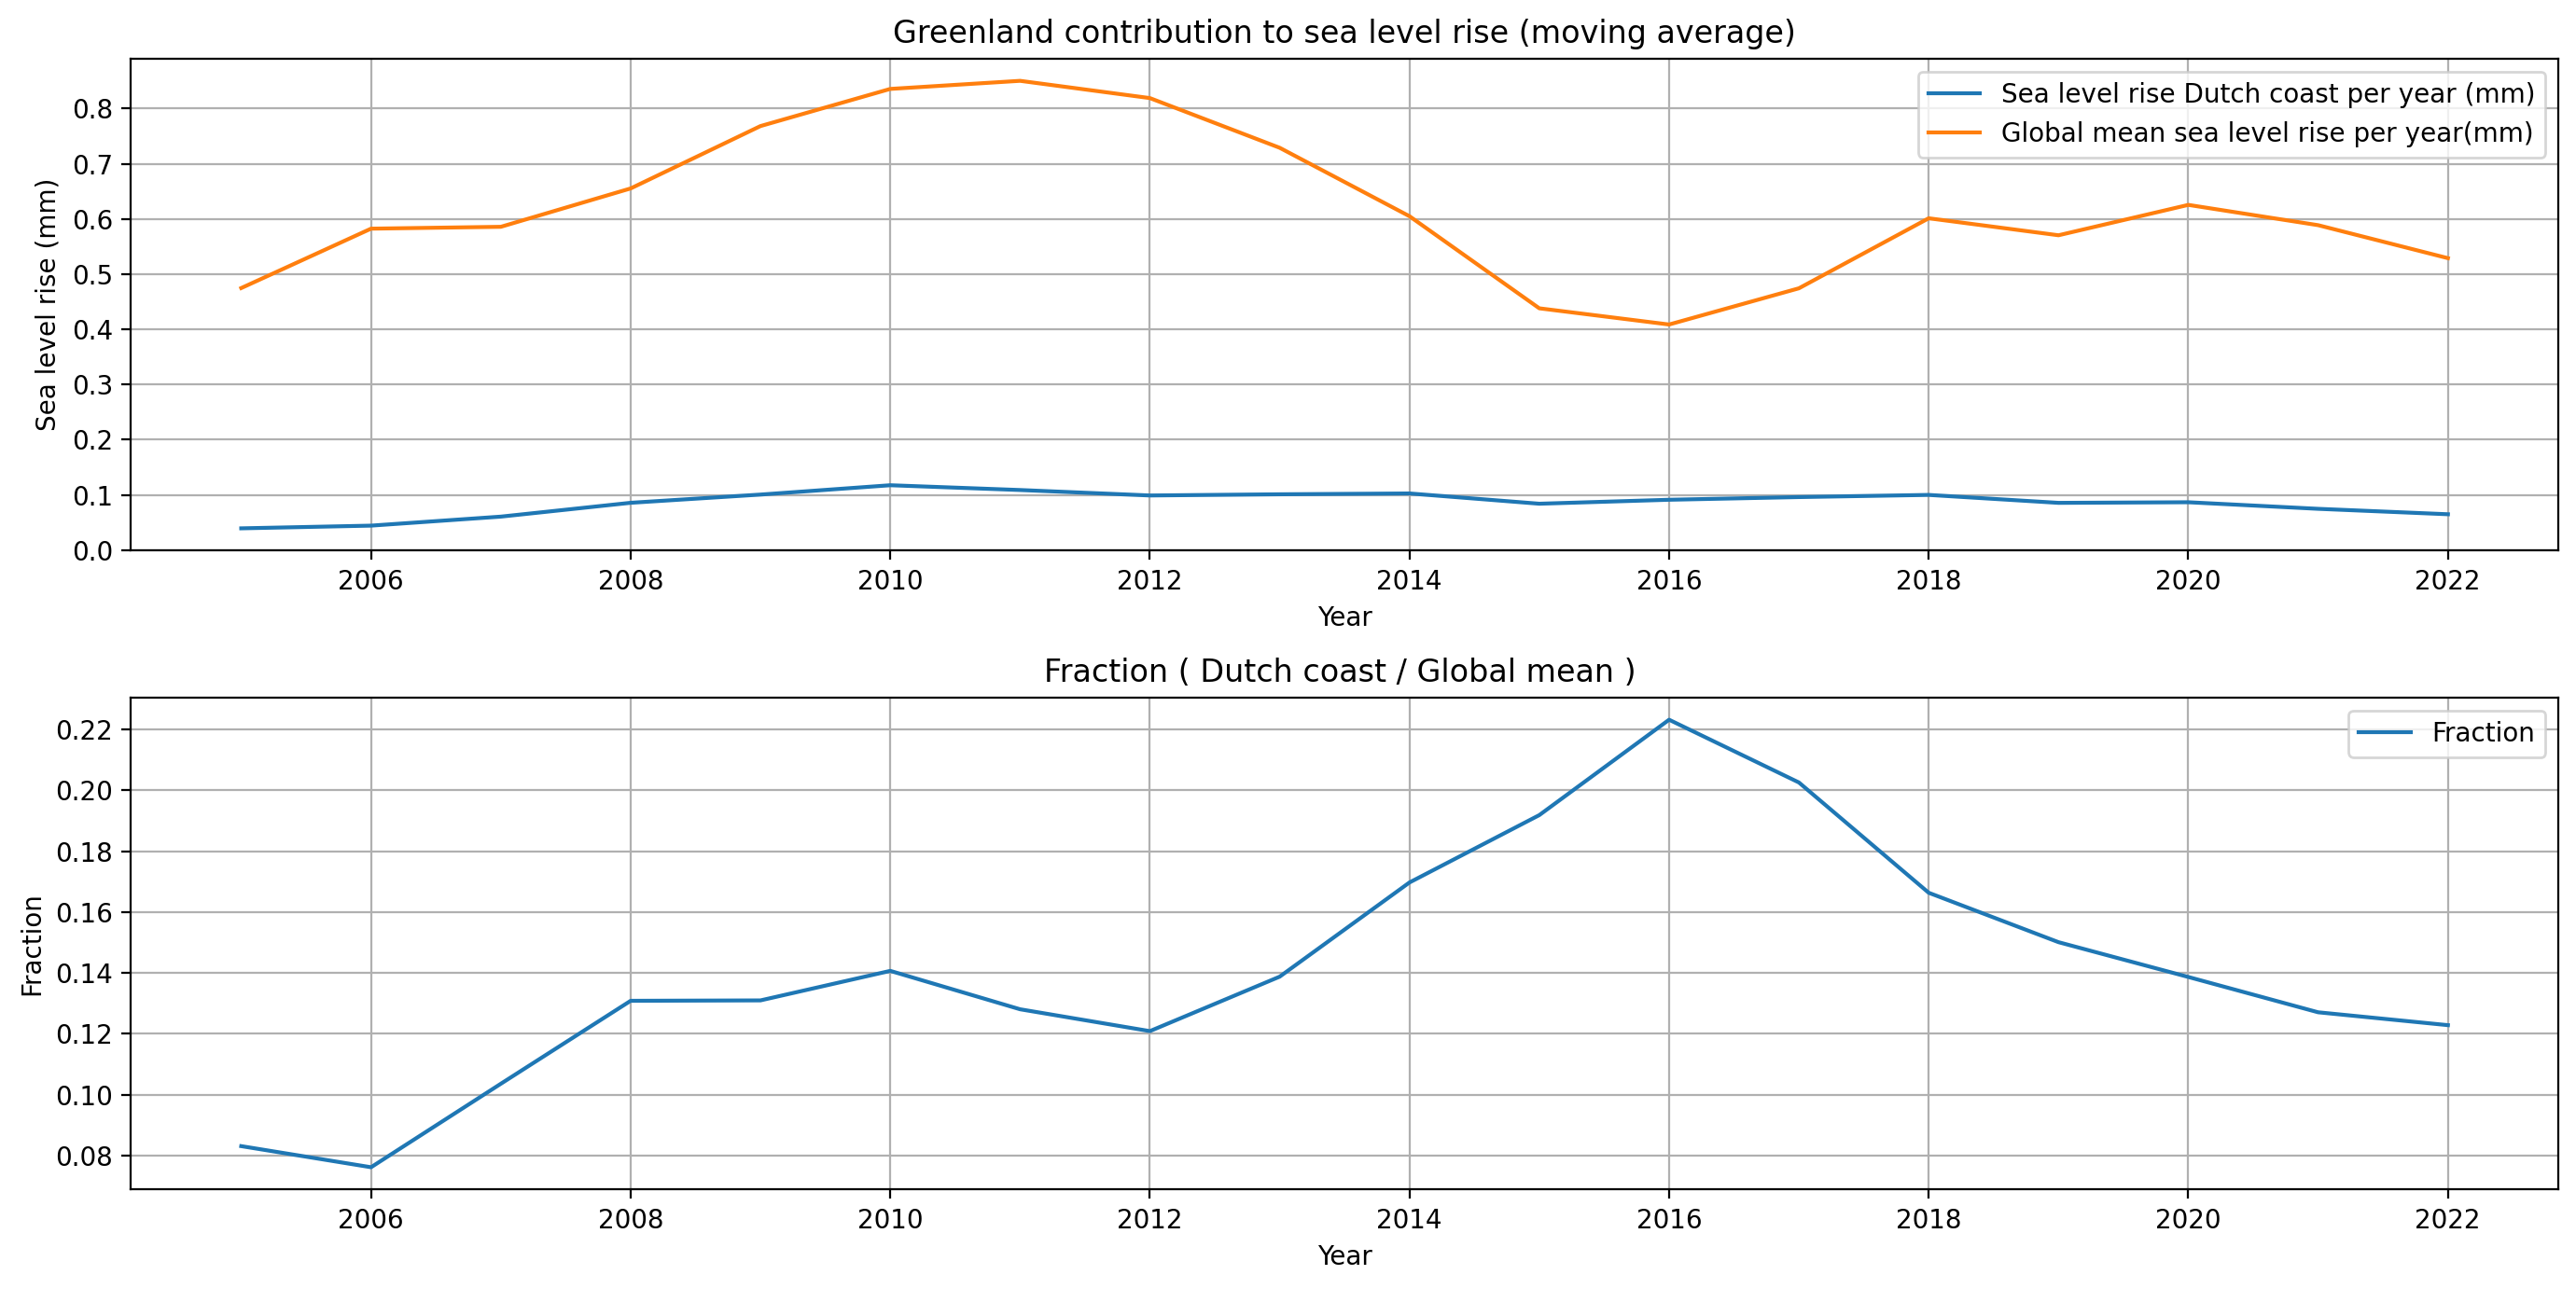

In [10]:
# Plot the sea level rise as a result of mass changes in Greenland. Plot the corresponding global mean and the value for the Dutch coast

from matplotlib.ticker import MaxNLocator

# Plot the two different figures in one window (stacked vertically)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7))

#Plot1
(dutch_c_5y*10).plot(ax=ax1, label='Sea level rise Dutch coast per year (mm)')  #translated to mm
(mean_w_5y*10).plot(ax=ax1, label='Global mean sea level rise per year(mm)')

ax1.set_title("Greenland contribution to sea level rise (moving average)")
ax1.set_xlabel("Year")
ax1.set_ylabel("Sea level rise (mm)")
ax1.legend()
ax1.xaxis.set_major_locator(MaxNLocator(integer=True))  # whole numbers
ax1.grid()

# Plot2
fractionperyearrun.plot(ax=ax2, label='Fraction')
#ax2.axhline(y=1, color='r', linestyle='--')

ax2.set_title("Fraction ( Dutch coast / Global mean ) ")
ax2.set_xlabel("Year")
ax2.set_ylabel("Fraction")
ax2.legend()
ax2.xaxis.set_major_locator(MaxNLocator(integer=True))  # whole numbers
ax2.grid()

plt.tight_layout()
plt.show()


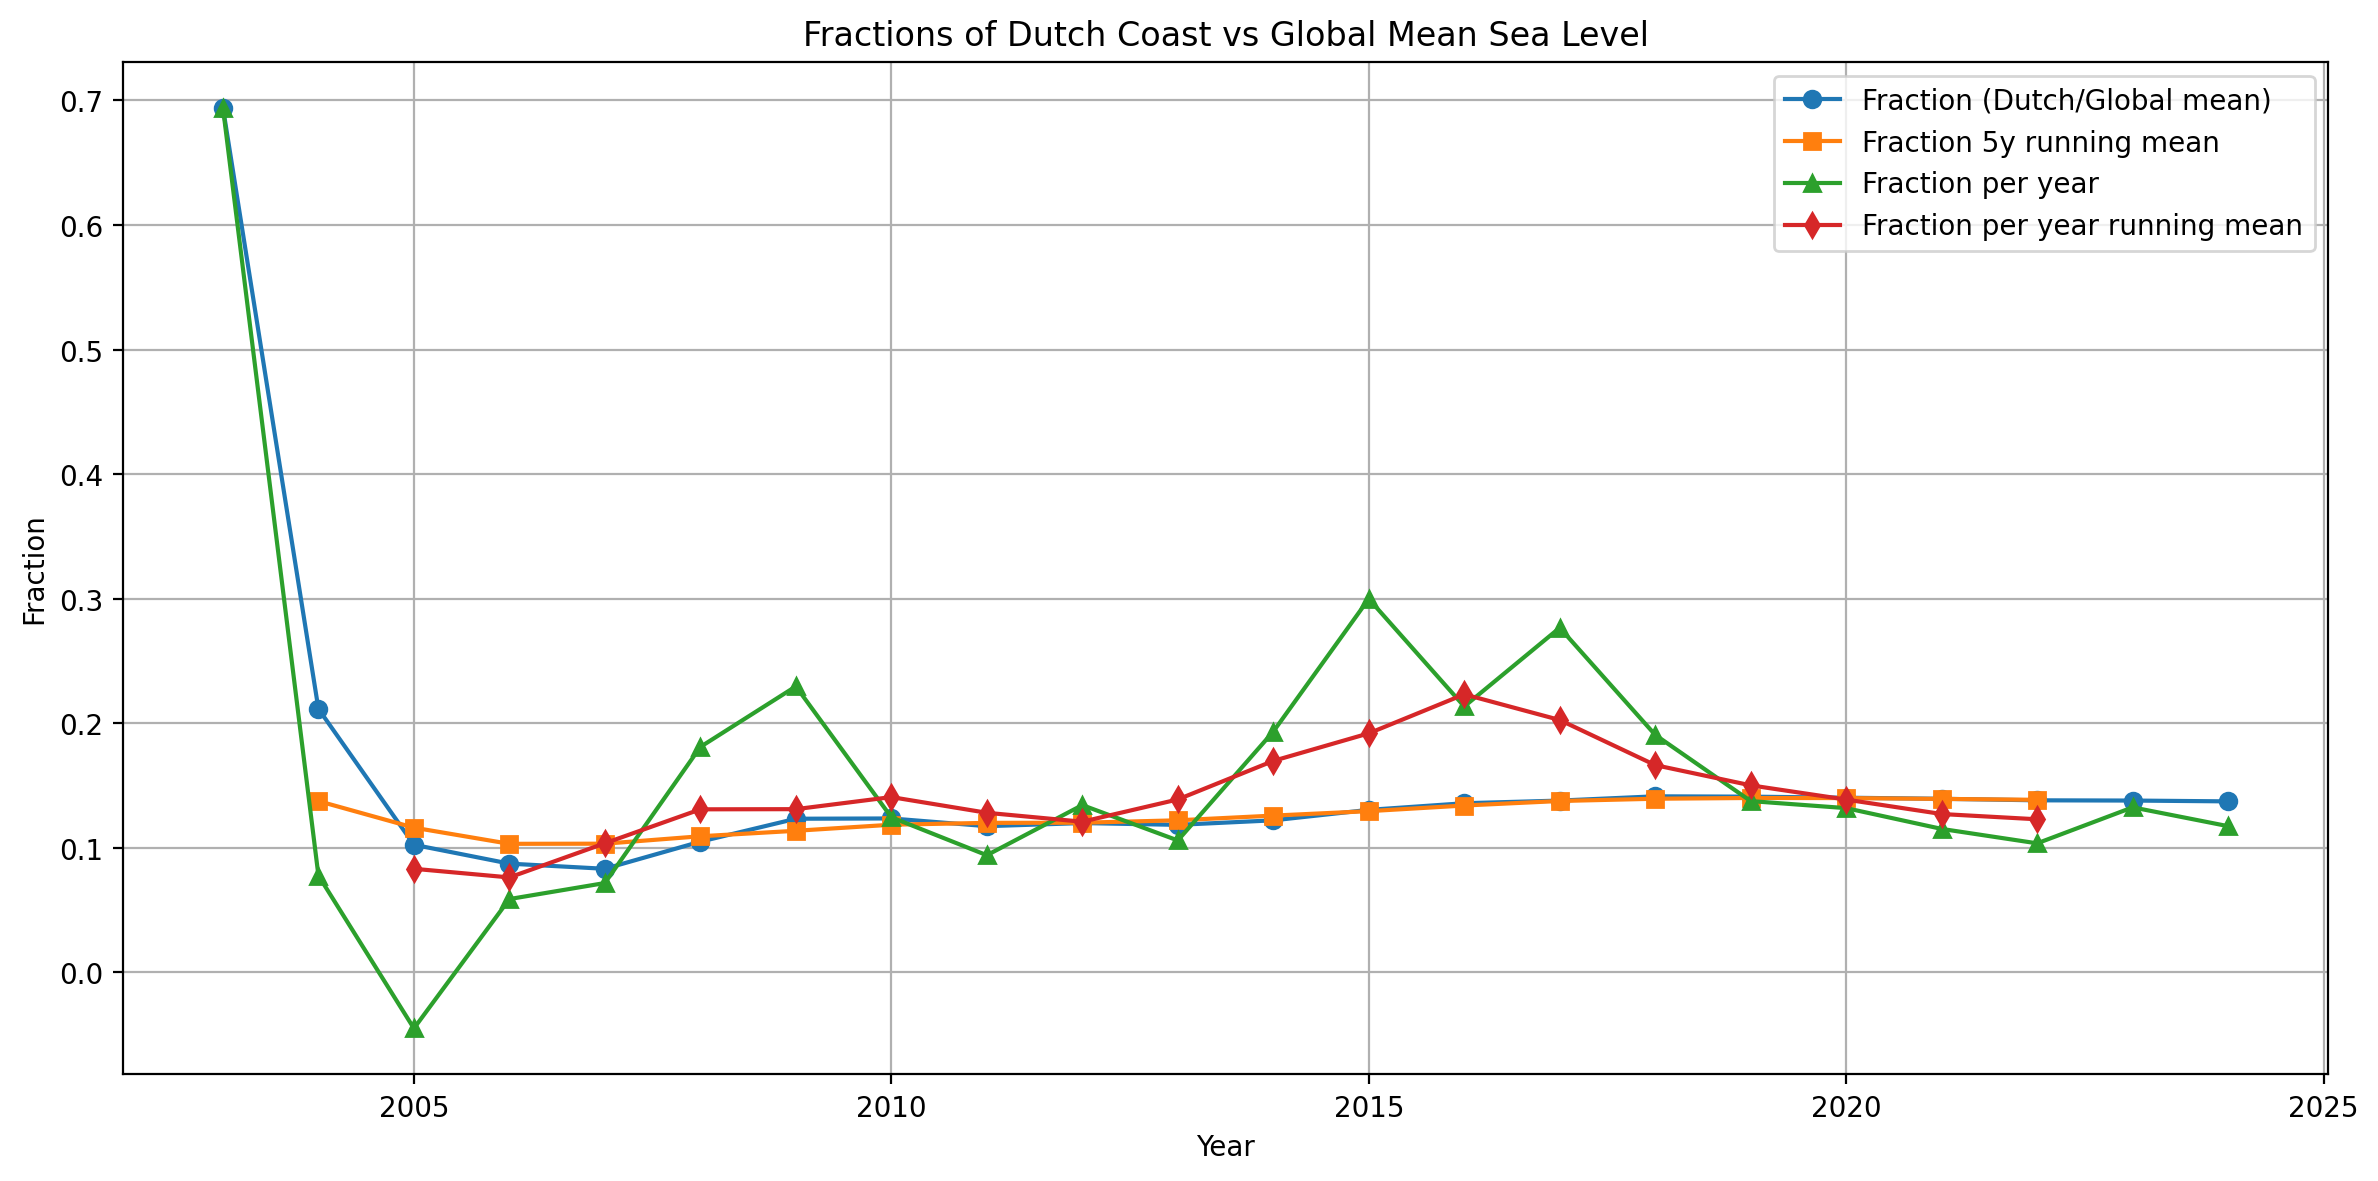

In [11]:
# Compare the fractions calculated based on the running mean, cummulative and yearly data and explore the differences 

plt.figure(figsize=(12,6))

# Plot each fraction series
plt.plot(fraction.index, fraction, label='Fraction (Dutch/Global mean)', marker='o')
plt.plot(fraction_5y.index, fraction_5y, label='Fraction 5y running mean', marker='s')
plt.plot(fractionperyear.index, fractionperyear, label='Fraction per year', marker='^')
plt.plot(fractionperyearrun.index, fractionperyearrun, label='Fraction per year running mean', marker='d')

# Labels and title
plt.xlabel('Year')
plt.ylabel('Fraction')
plt.title('Fractions of Dutch Coast vs Global Mean Sea Level')
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.show()


In [12]:

dutch1 = dutch_coast.loc[2008] - dutch_coast.loc[2003] 
world1 = mean_world.loc[2008] - mean_world.loc[2003] 
frac1 = dutch1/world1
print(frac1) 

dutch2 = dutch_coast.loc[2014] - dutch_coast.loc[2009] 
world2 = mean_world.loc[2014] - mean_world.loc[2009] 
frac2 = dutch2/world2
print(frac2) 

dutch3 = dutch_coast.loc[2019] - dutch_coast.loc[2014] 
world3 = mean_world.loc[2019] - mean_world.loc[2014] 
frac3 = dutch3/world3
print(frac3)

dutch4 = dutch_coast.loc[2024] - dutch_coast.loc[2019] 
world4 = mean_world.loc[2024] - mean_world.loc[2019] 
frac4 = dutch4/world4
print(frac4)


0.07614047393250199
0.12086298836940189
0.20255057831568116
0.1228182421691712


In [13]:
#Plotjes maken: 
print(gre_y['dm'].sel(time='2002').squeeze().shape)

diff1 = gre_y['dm'].sel(time='2008').squeeze() - gre_y['dm'].sel(time='2003').squeeze()  # squeeze removes the time dimension (without dimension is (1,x,y) and now (x,y), with isel it is removed automatically. 
diff2 = gre_y['dm'].sel(time='2014').squeeze() - gre_y['dm'].sel(time='2009').squeeze()
diff3 = gre_y['dm'].sel(time='2019').squeeze() - gre_y['dm'].sel(time='2014').squeeze() 
diff4 = gre_y['dm'].sel(time='2024').squeeze() - gre_y['dm'].sel(time='2019').squeeze()

mean1 = diff1/5
mean2 = diff2/5
mean3 = diff3/5
mean4 = diff4/5

#print(gre_y['time'].values)

(55, 36)


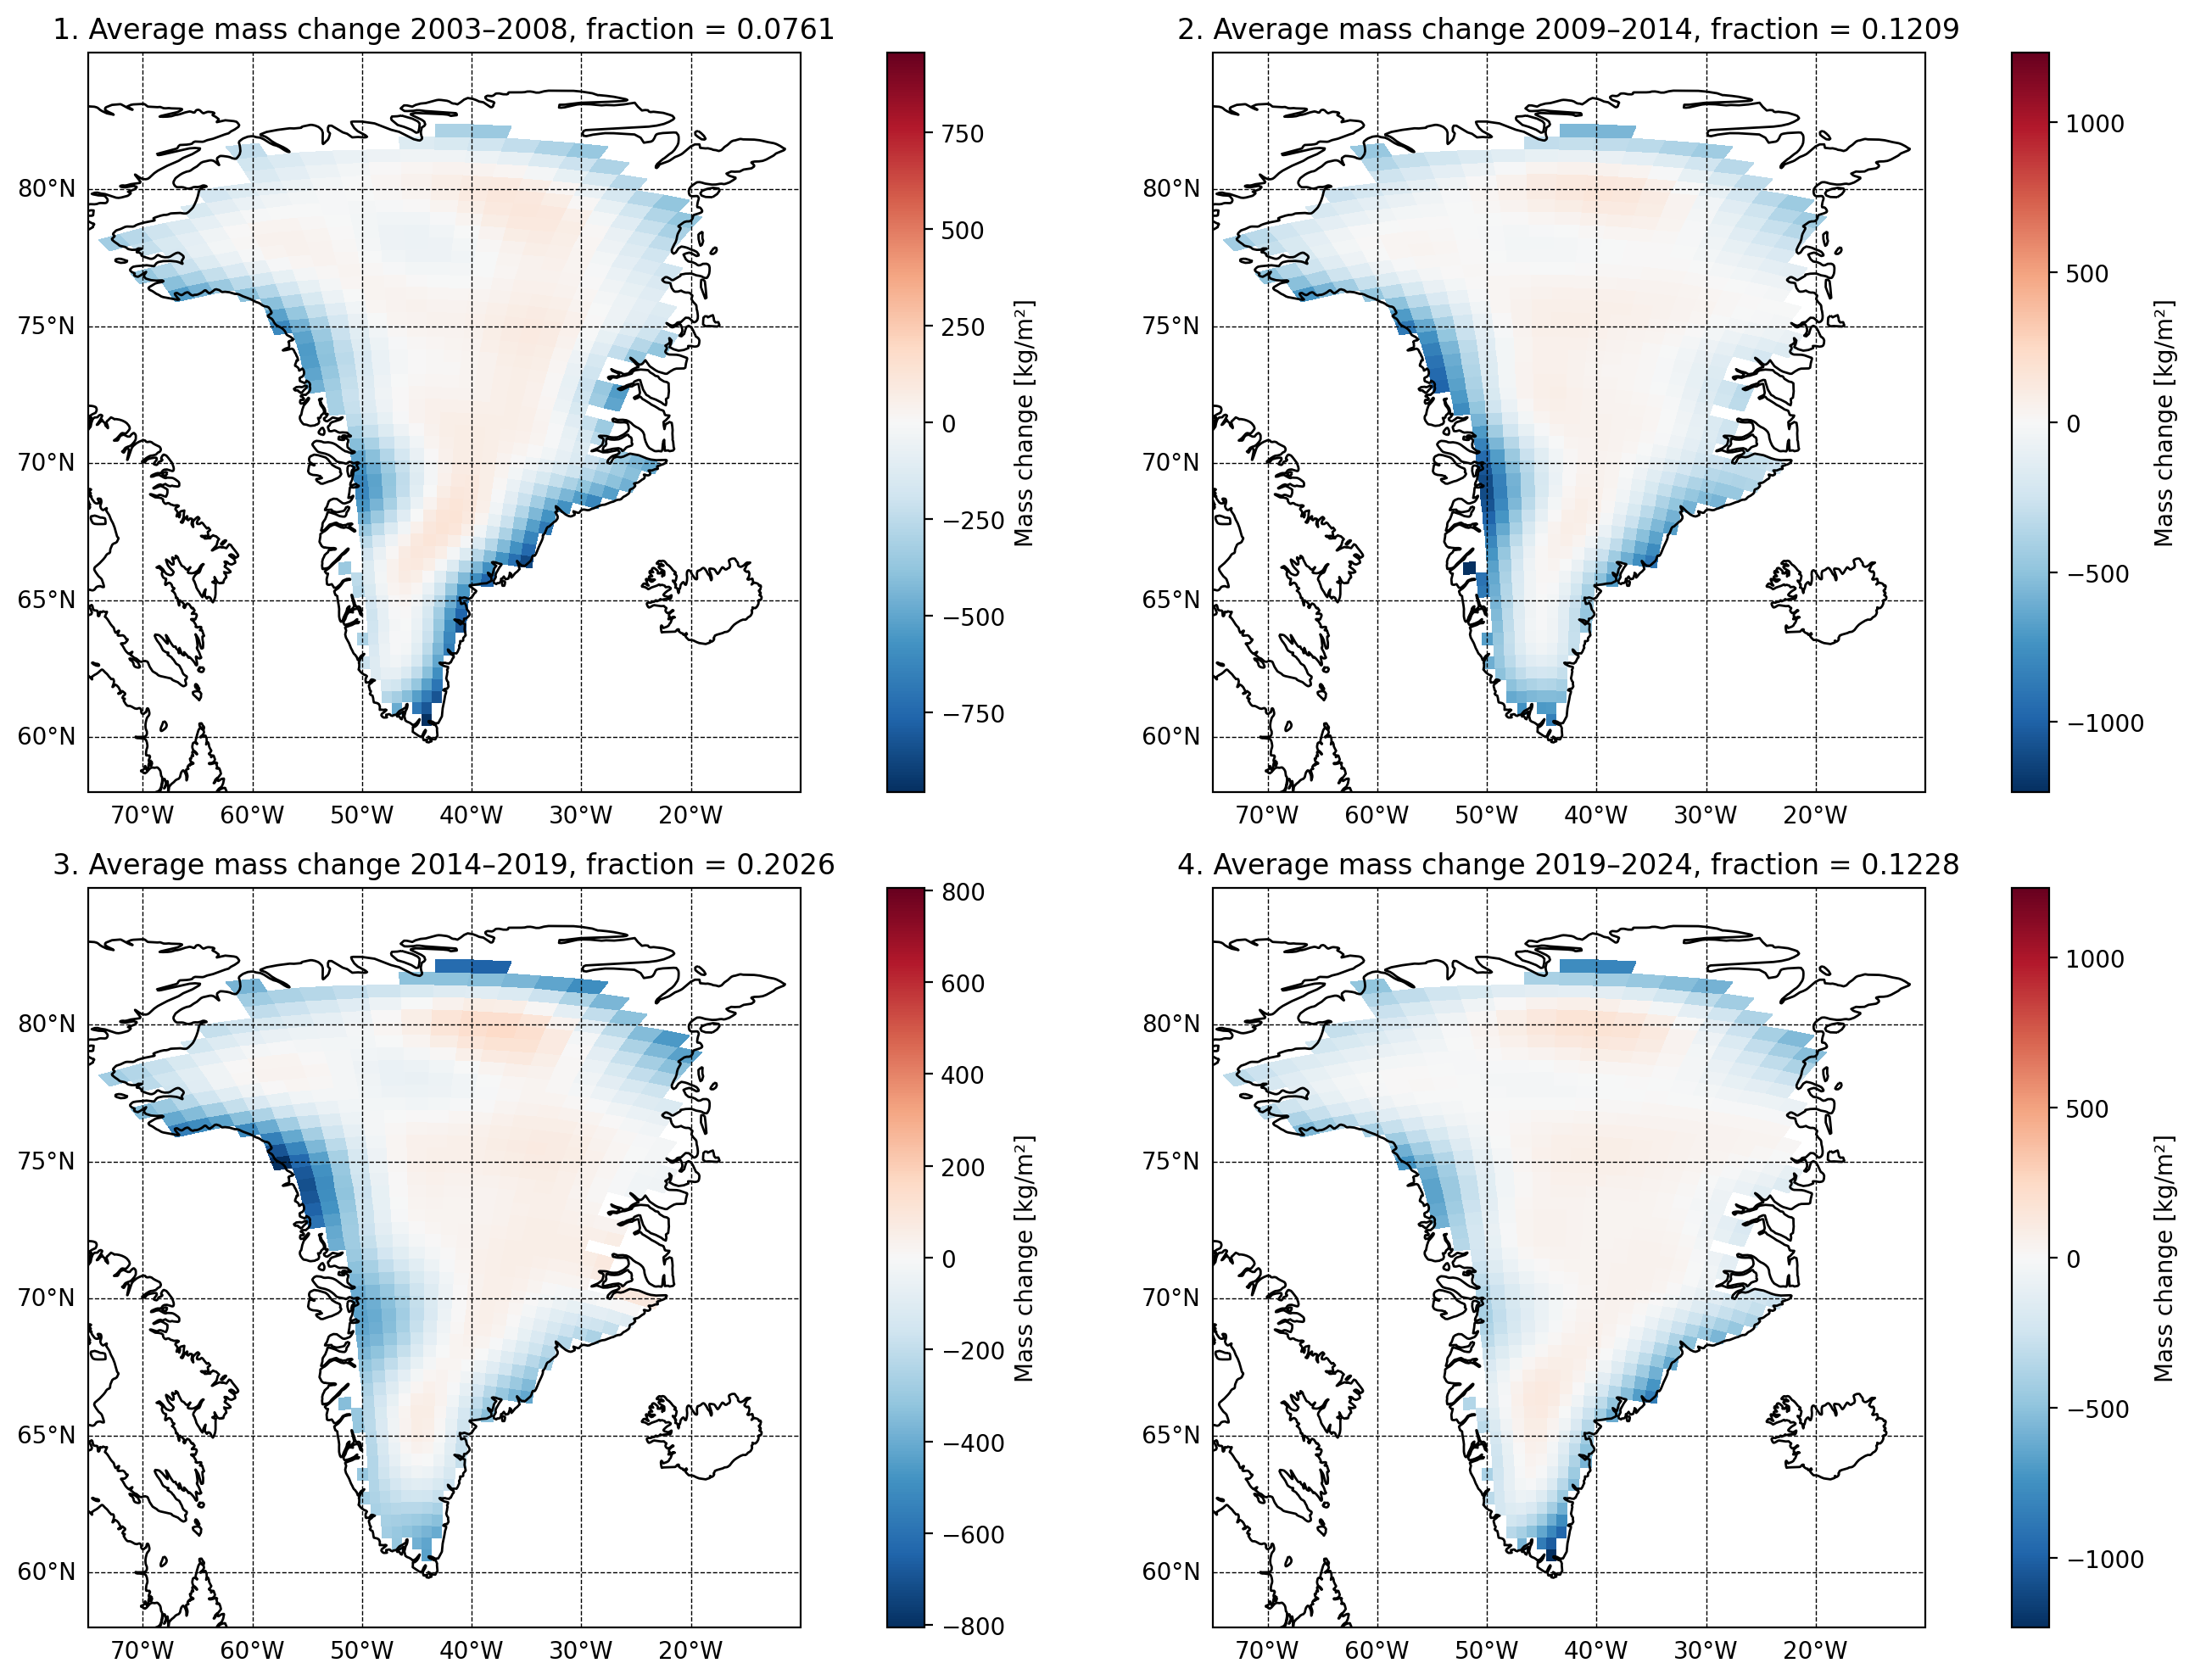

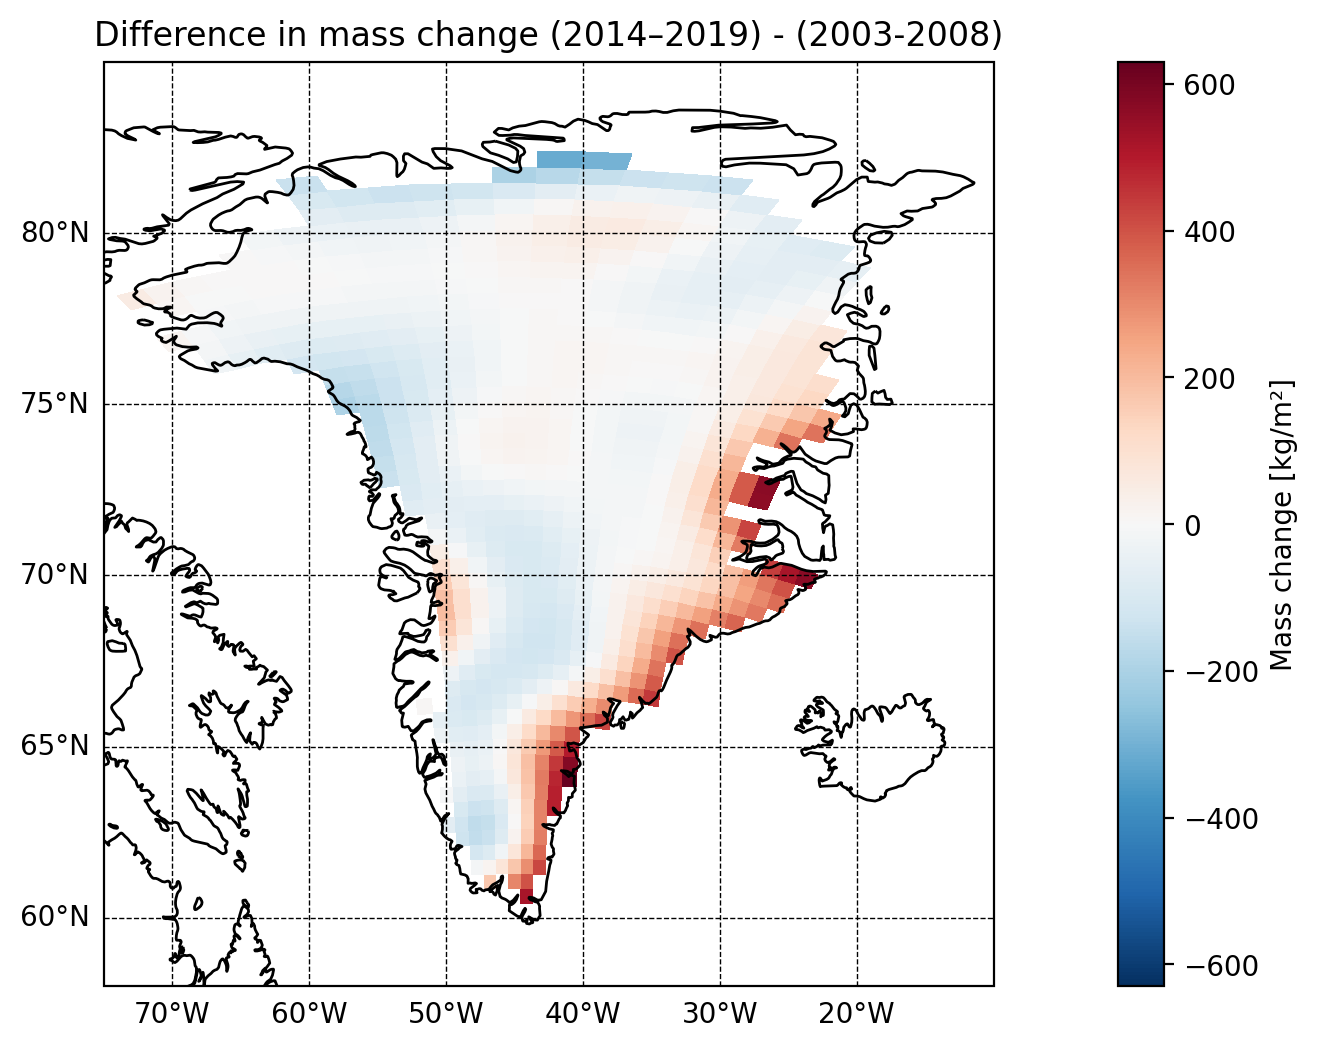

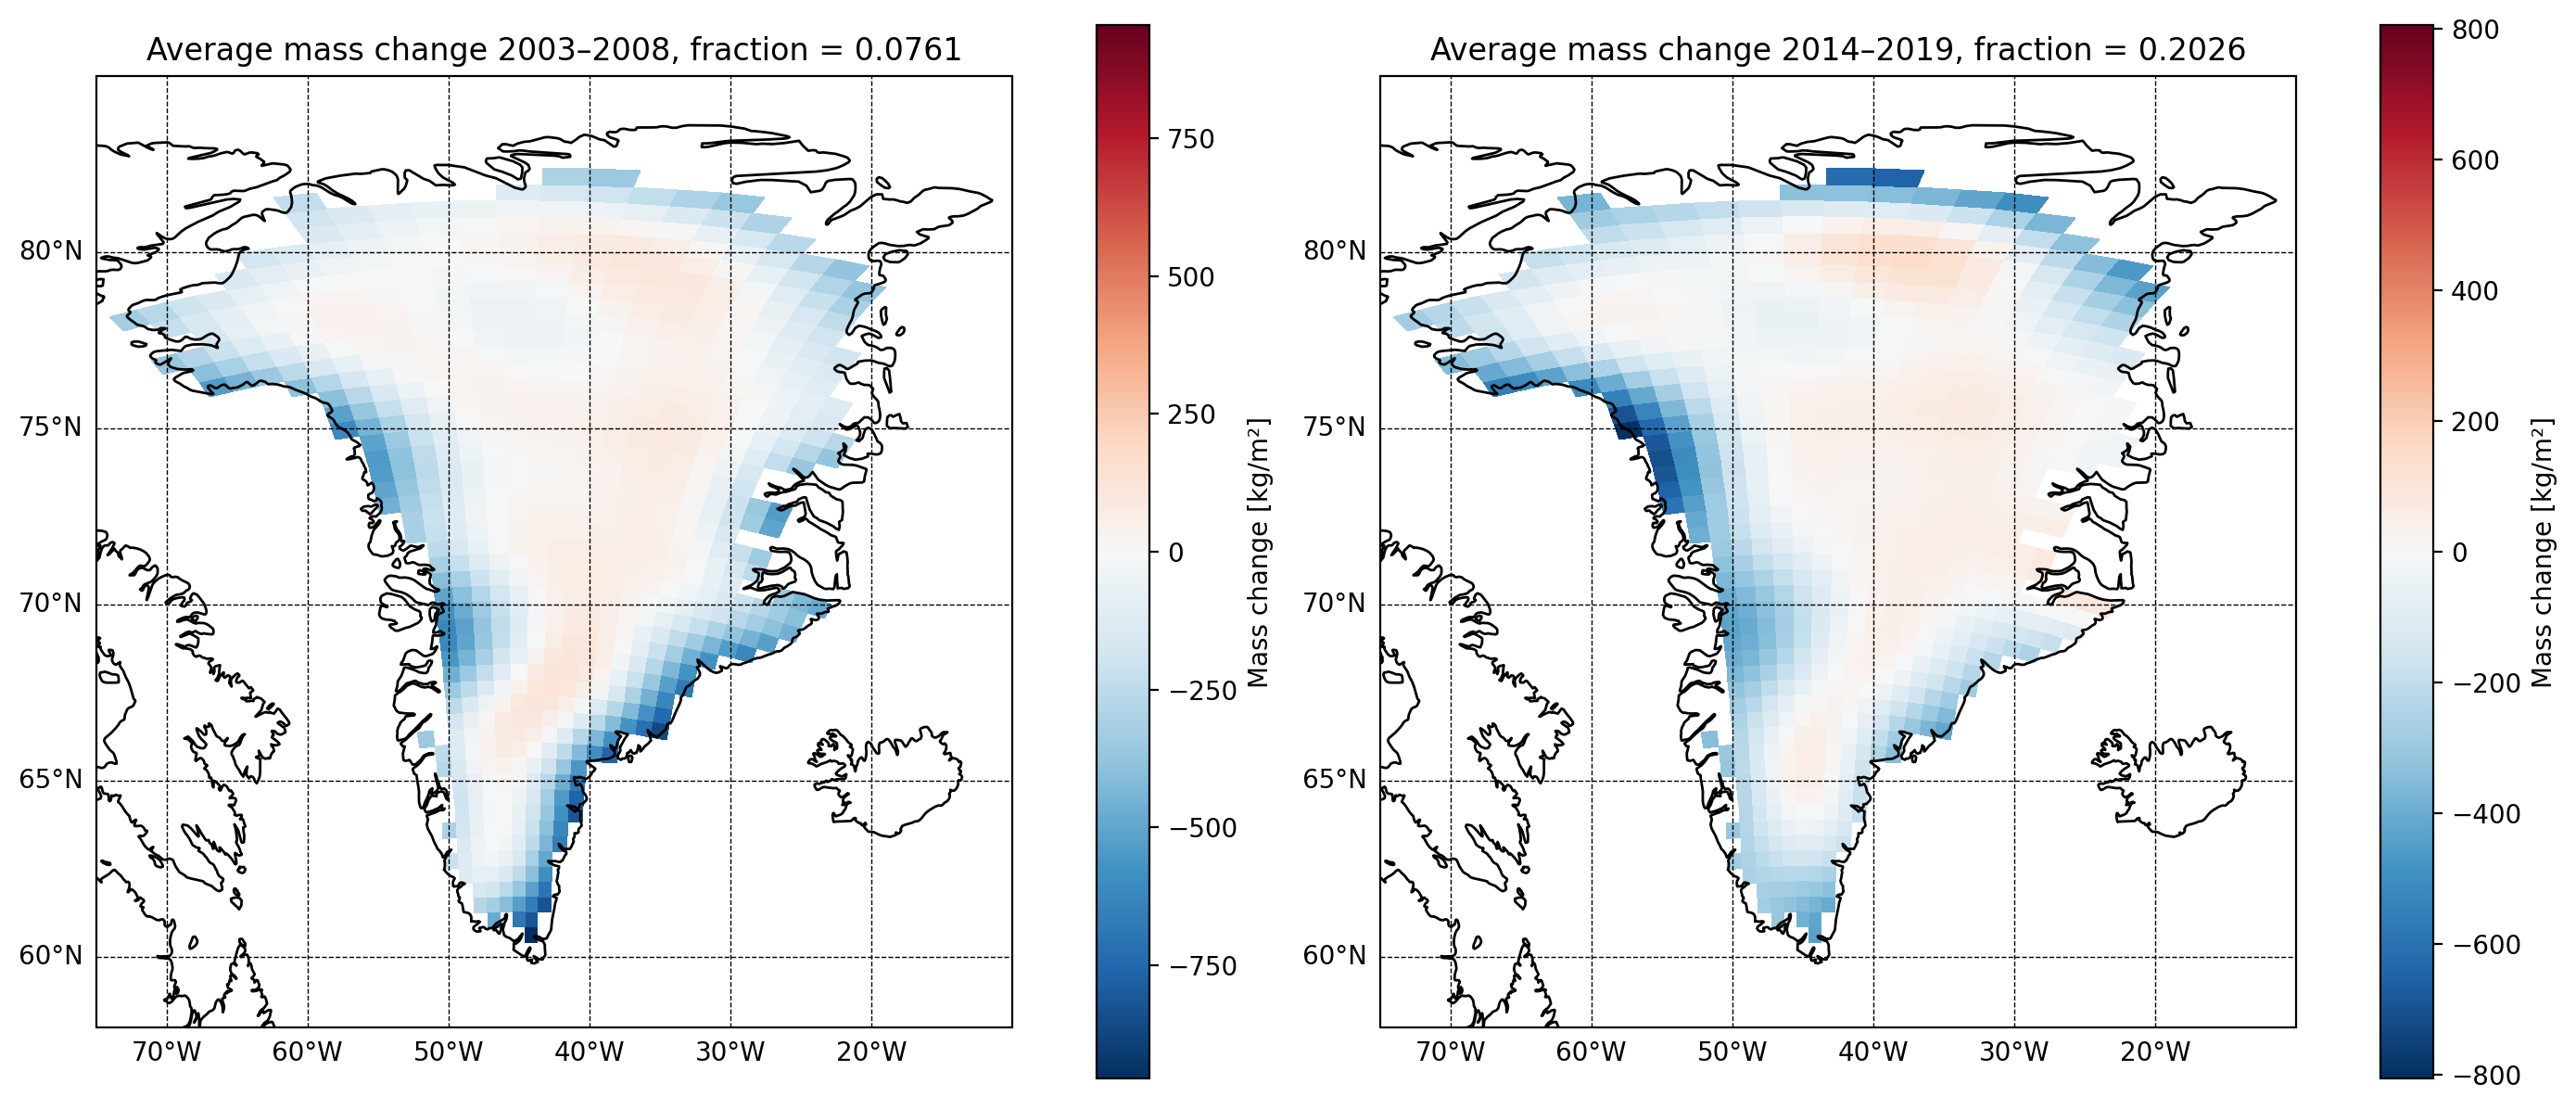

In [14]:

# lon/lat arrays
lon = gre_y['lon']
lat = gre_y['lat']



def plot_field(ax, data, title):
    absmax = np.nanmax(np.abs(data))
    vmin, vmax = -absmax, absmax

    ax.set_extent(extent, crs=ccrs.PlateCarree())
    #ax.coastlines()
    gl = ax.gridlines(
        draw_labels=True,       # optional: show lat/lon labels
        linewidth=0.5,          # line thickness
        color='black',           # color of gridlines
        linestyle='--'          # dashed style
    )

    # set the label colors to gray
    gl.top_labels = False      # usually top labels not needed
    gl.right_labels = False    # usually right labels not needed
    gl.xlabel_style = {'color': 'black'}
    gl.ylabel_style = {'color': 'black'}


    # >>> vertically stretch the map <<<
    ax.set_aspect(2.5)      # increase this number for more stretching

    mesh = ax.pcolormesh(
        lon, lat, data,
        cmap='RdBu_r',
        vmin=vmin, vmax=vmax,
        transform=ccrs.PlateCarree()
   )

    ax.coastlines()
            
   # mesh = ax.contourf(lon, lat, data,
   #                       #levels=30, 
   #                       transform=ccrs.PlateCarree(),
   #                       cmap='RdBu_r',
   #                       extend='both')


    ax.set_title(title)

    plt.colorbar(
        mesh, ax=ax,
        orientation='vertical',
        pad=0.08,
        fraction=0.05,
        label='Mass change [kg/m²]'
    )



# ---- CREATE A TALLER FIGURE ----
fig, axes = plt.subplots(
    2, 2,
    figsize=(14, 10),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

ax1, ax2, ax3, ax4 = axes.flatten()
extent = [-75, -10, 58, 85] 



plot_field(ax1, mean1, f'1. Average mass change 2003–2008, fraction = {frac1:.4f}')
plot_field(ax2, mean2, f'2. Average mass change 2009–2014, fraction = {frac2:.4f}')
plot_field(ax3, mean3, f'3. Average mass change 2014–2019, fraction = {frac3:.4f}')
plot_field(ax4, mean4, f'4. Average mass change 2019–2024, fraction = {frac4:.4f}')



plt.tight_layout()
plt.show()


# Compute difference
diff = mean3 - mean1


# Create a single figure
fig, ax = plt.subplots(
    1, 1,
    figsize=(10, 6),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

# Plot using the same function
plot_field(ax, diff, f'Difference in mass change (2014–2019) - (2003-2008)')

plt.show()




fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 9),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

ax1, ax3 = axes

plot_field(ax1, mean1, f'Average mass change 2003–2008, fraction = {frac1:.4f}')
plot_field(ax3, mean3, f'Average mass change 2014–2019, fraction = {frac3:.4f}')

plt.tight_layout()
plt.show()





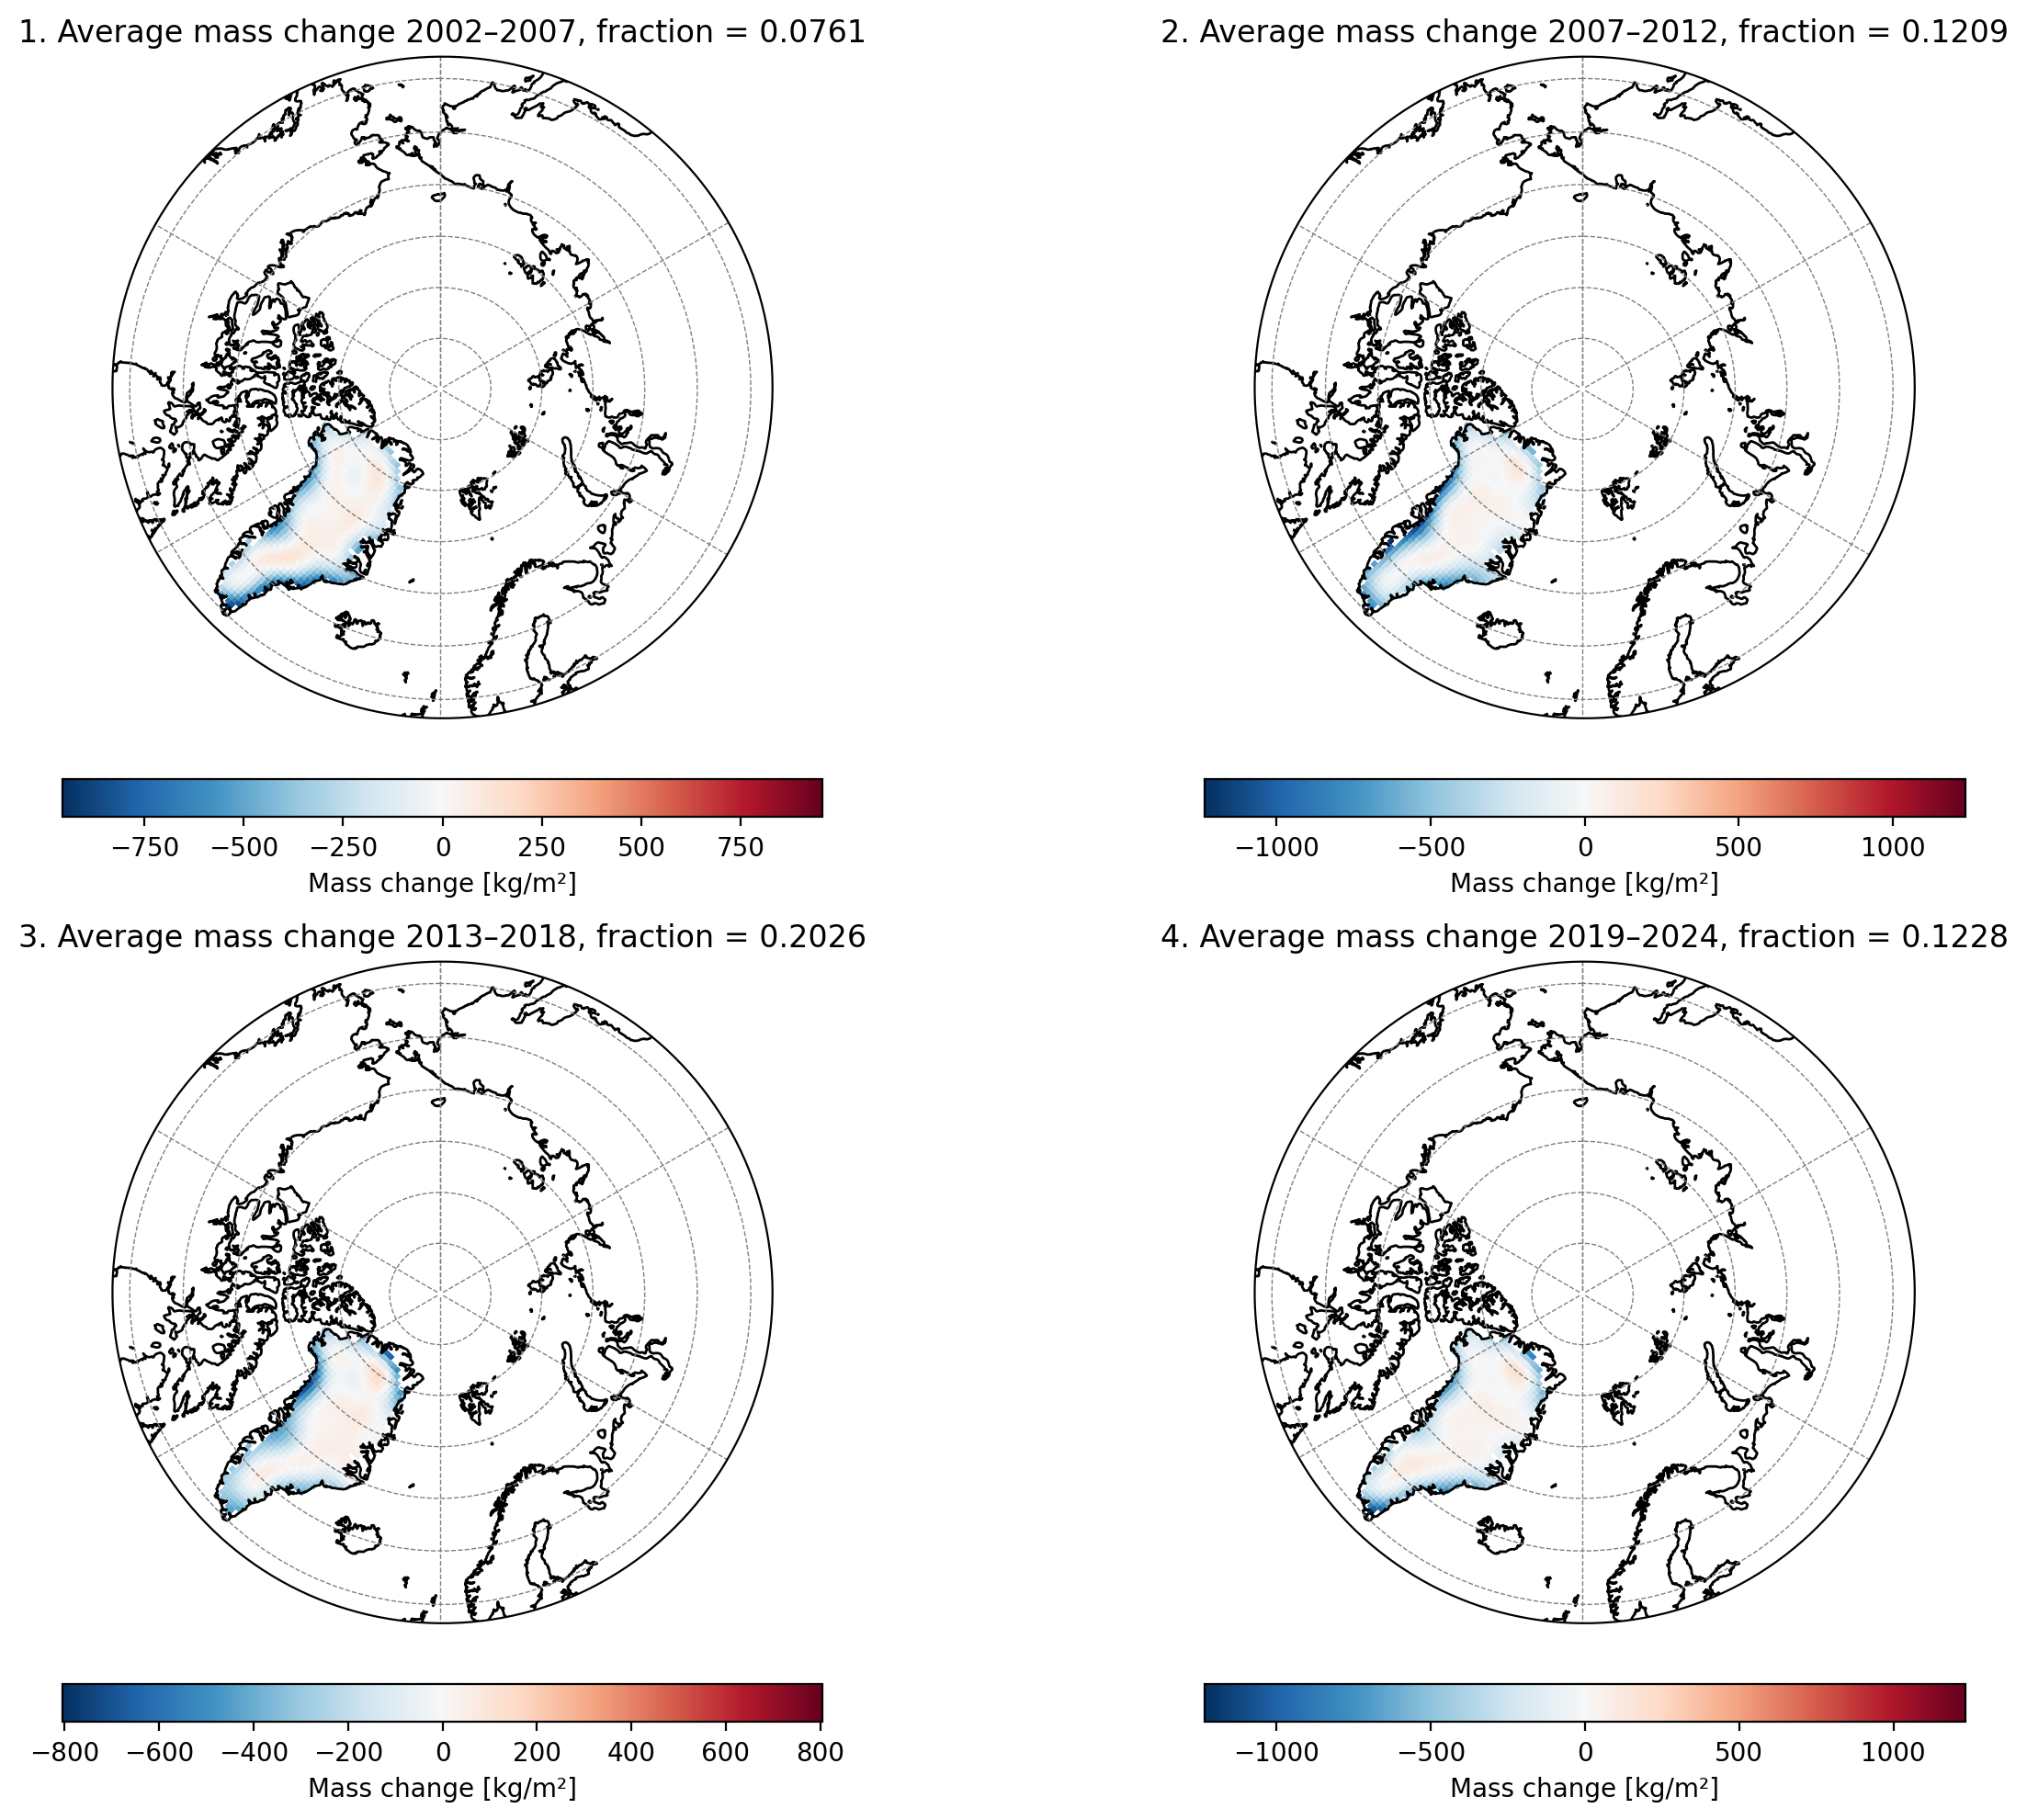

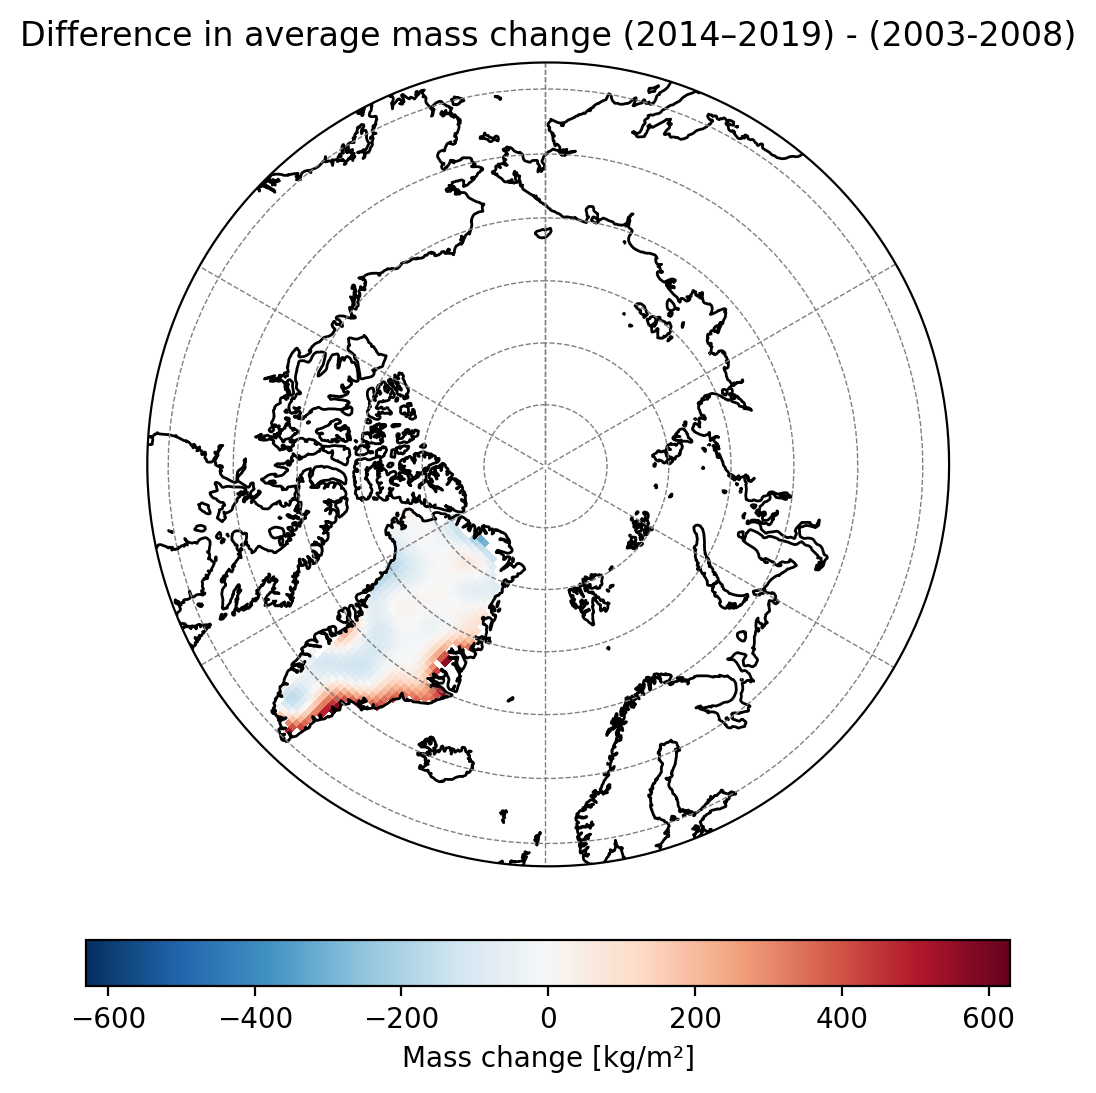

In [19]:
# Try different projection

# lon/lat arrays
lon = gre_y['lon']
lat = gre_y['lat']

# Use North Polar Stereographic projection
proj = ccrs.NorthPolarStereo()

# IMPORTANT: extent must be in projection coordinates,
# but Cartopy lets you give lon/lat if you specify the crs.
extent = [-180, 180, 58, 90]   # lon_min, lon_max, lat_min, lat_max

from matplotlib.path import Path

def plot_field(ax, data, title):
    absmax = np.nanmax(np.abs(data))
    vmin, vmax = -absmax, absmax

    ax.set_extent([-180, 180, 58, 90], crs=ccrs.PlateCarree())
    ax.coastlines()

    # ---- Fix: circular boundary using Path ----
    theta = np.linspace(0, 2*np.pi, 200)
    circle = np.vstack([0.5 + 0.5*np.cos(theta),
                        0.5 + 0.5*np.sin(theta)]).T
    circle_path = Path(circle)

    ax.set_boundary(circle_path, transform=ax.transAxes)

    # Gridlines (no labels for polar projection)
    gl = ax.gridlines(
        draw_labels=False,
        linewidth=0.5,
        color='gray',
        linestyle='--'
    )

    mesh = ax.pcolormesh(
        lon, lat, data,
        cmap='RdBu_r',
        vmin=vmin, vmax=vmax,
        transform=ccrs.PlateCarree()
    )

    ax.set_title(title)

    plt.colorbar(
        mesh, ax=ax,
        orientation='horizontal',
        pad=0.08,
        fraction=0.05,
        label='Mass change [kg/m²]'
    )



# ---- CREATE A TALLER FIGURE ----
fig, axes = plt.subplots(
    2, 2,
    figsize=(14, 10),
    subplot_kw={'projection': proj}
)

ax1, ax2, ax3, ax4 = axes.flatten()

plot_field(ax1, mean1, f'1. Average mass change 2002–2007, fraction = {frac1:.4f}')
plot_field(ax2, mean2, f'2. Average mass change 2007–2012, fraction = {frac2:.4f}')
plot_field(ax3, mean3, f'3. Average mass change 2013–2018, fraction = {frac3:.4f}')
plot_field(ax4, mean4, f'4. Average mass change 2019–2024, fraction = {frac4:.4f}')

plt.tight_layout()
plt.show()


# ---- Difference plot ----
diff = mean3 - mean1

fig, ax = plt.subplots(
    1, 1,
    figsize=(10, 6),
    subplot_kw={'projection': proj}
)

plot_field(ax, diff, f'Difference in average mass change (2014–2019) - (2003-2008)')

plt.show()





